In [24]:
from astropy import units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import EventList
from gammapy.datasets import Datasets, MapDataset
from gammapy.irf import EDispKernelMap, PSFMap
from gammapy.maps import Map, MapAxis, WcsGeom
from gammapy.modeling import Fit
from matplotlib.patches import Circle
from gammapy.modeling.models import (
    Models,
    PointSpatialModel,
    PowerLawNormSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpatialModel,
    create_fermi_isotropic_diffuse_model,
)
from astropy.table import vstack
from gammapy.data import EventList
from gammapy.catalog import SourceCatalog4FGL

import yaml
from fermipy.gtanalysis import GTAnalysis
import os
import numpy as np
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter, SEDPlotter
import matplotlib.pyplot as plt
import matplotlib

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [2]:
# Create a GTAnalysis object from the configuration file.
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/fermi_config_sgr1900.yaml', logging={'verbosity': 3})

2025-04-15 16:57:34 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0


In [3]:
gta.config

{'logging': {'prefix': '', 'chatter': 3, 'verbosity': 3},
 'fileio': {'outdir': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_with_model',
  'scratchdir': '/scratch',
  'workdir': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_with_model',
  'logfile': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_with_model/fermipy.log',
  'savefits': True,
  'workdir_regex': ['\\.fits$|\\.fit$|\\.xml$|\\.npy$'],
  'outdir_regex': ['\\.fits$|\\.fit$|\\.xml$|\\.npy$|\\.png$|\\.pdf$|\\.yaml$'],
  'usescratch': False},
 'optimizer': {'optimizer': 'MINUIT',
  'tol': 0.001,
  'max_iter': 100,
  'init_lambda': 0.0001,
  'retries': 3,
  'min_fit_quality': 2,
  'verbosity': 0},
 'binning': {'projtype': 'WCS',
  'proj': 'AIT',
  'coordsys': 'GAL',
  'npix': None,
  'roiwidth': 1.4,
  'binsz': 0.05,
  'binsperdec': 8.0,
  'enumbins': None,
  'hpx_ordering_scheme': 'RING',
  'hpx_order': 10,
  'hpx_ebin'

In [4]:
gta.setup()

2025-04-15 16:57:40 INFO    GTAnalysis.setup(): Running setup.
2025-04-15 16:57:40 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-04-15 16:57:40 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2025-04-15 16:57:40 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2025-04-15 16:57:40 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
Set MJD-OBS to 54682.655283 from DATE-OBS.
Set MJD-END to 60774.984781 from DATE-END'. [astropy.wcs.wcs]
2025-04-15 16:57:40 INFO    GTBinnedAnalysis._create_srcmaps(): Skipping gtsrcmaps.
2025-04-15 16:57:40 INFO    GTBinnedAnalysis.setup(): Finished setup for component 00
2025-04-15 16:57:40 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2025-04-15 16:57:43 INFO    GTAnalysis.setup(): Initializing source properties
2025-04-15 16:57:44 INFO    GTAnalysis.setup(): Finished setup.


In [5]:
gta.print_model()

2025-04-15 16:58:05 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   1.276  1.11e-05   2.20       nan      1193.8     
4FGL J1910.2+0904c     0.430   0.394     1e-05   2.29       nan      1230.4     
4FGL J1911.0+0905      0.619   0.756  5.62e-05   2.21       nan      6644.4     
4FGL J1912.0+0927      0.869   0.320  3.88e-06   2.95       nan       469.7     
isodiff                  ---   1.000    0.0327   2.12       nan       199.2     
galdiff                  ---   1.000     0.133   0.00       nan     26294.4     



In [6]:
gta.free_sources()

2025-04-15 16:58:29 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1908.6+0915e    : ['Prefactor', 'Index']
2025-04-15 16:58:29 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1910.2+0904c    : ['Prefactor', 'Index']
2025-04-15 16:58:29 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1911.0+0905     : ['norm', 'alpha', 'beta']
2025-04-15 16:58:29 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1912.0+0927     : ['norm', 'alpha', 'beta']
2025-04-15 16:58:29 INFO    GTAnalysis.free_source(): Freeing parameters for isodiff               : ['Normalization']
2025-04-15 16:58:29 INFO    GTAnalysis.free_source(): Freeing parameters for galdiff               : ['Prefactor', 'Index']


In [7]:
gta.fit()

2025-04-15 16:58:36 INFO    GTAnalysis.fit(): Starting fit.
2025-04-15 16:58:37 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-04-15 16:58:37 INFO    GTAnalysis.fit(): LogLike:    36678.344 DeltaLogLike:       16.596 


Drm_Cache::update Measured counts < 0 4FGL J1912.0+0927 22 -9.13744e-13 1.03565e-12
165.196 145.865 110.819 72.8422 41.7619 21.0514 9.47786 3.8119 1.33637 0.410196 0.11016 0.0266497 0.00567652 0.001054 0.000170838 2.4498e-05 3.09983e-06 3.4844e-07 3.48588e-08 3.10263e-09 2.44223e-10 1.69666e-11 1.03565e-12 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 16.59595898376574,
 'edm': 0.0002408092679795186,
 'loglike': 36678.34419737866,
 'covariance': array([[ 7.16890201e-02,  4.05497844e-02, -1.09500310e-03,
         -1.26583049e-03,  4.79753449e-04,  1.79929527e-04,
          9.29438230e-05,  2.19025940e-03, -2.56474702e-03,
         -2.36392111e-03, -1.11944564e-03,  1.87090499e-03,
         -3.54411172e-06],
        [ 4.05497844e-02,  4.43699932e-02, -5.15338340e-04,
         -2.13426663e-03,  2.48734557e-05,  4.93340649e-04,
         -3.65561513e-04,  1.08835707e-03,  1.15782978e-03,
         -1.68633288e-03, -1.25590417e-03,  2.46137599e-04,
          1.07644283e-07],
        [-1.09500310e-03, -5.15338340e-04,  1.59322979e-03,
         -2.49247604e-04, -2.42079118e-04, -1.78993770e-04,
          4.26589993e-05,  1.47284273e-04,  4.50874171e-04,
         -1.66938968e-04, -3.06998281e-05,  4.12160173e-06,
          2.89434468e-07],
        [-1.26583049e-03, -2.134

2025-04-15 17:01:53 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_with_model/initial_00.xml...
2025-04-15 17:01:53 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_with_model/initial.fits...
2025-04-15 17:01:55 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.
2025-04-15 17:01:55 INFO    GTAnalysis.write_roi(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_with_model/initial.npy...


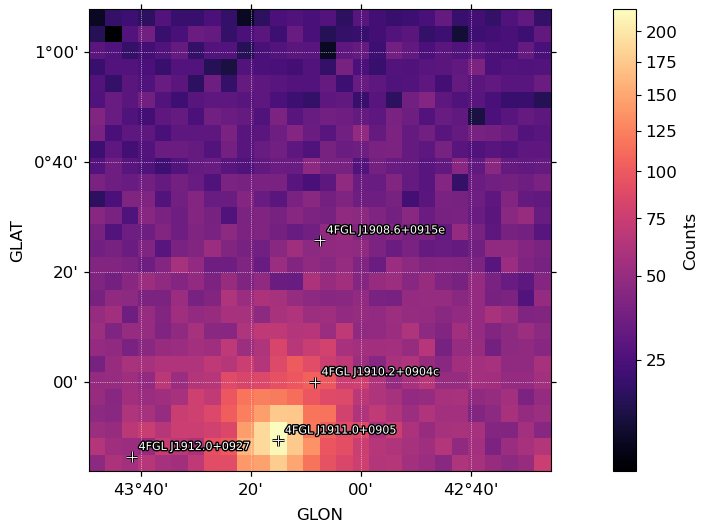

In [16]:
gta.write_roi('initial',make_plots=True,save_model_map=True)
plt.show()

In [11]:
gta.load_roi('initial')

2025-04-15 17:00:27 INFO    GTAnalysis.load_roi(): Loading ROI file: /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_with_model/initial.npy
2025-04-15 17:00:27 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2025-04-15 17:00:29 INFO    GTAnalysis.load_roi(): Finished Loading ROI


In [12]:
gta.print_model()

2025-04-15 17:00:43 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   0.407   6.8e-06   1.85      9.66       344.0    *
4FGL J1910.2+0904c     0.430   0.401  9.98e-06   2.36    169.14      1344.4    *
4FGL J1911.0+0905      0.619   0.702  5.41e-05   2.21   4707.35      6209.4    *
4FGL J1912.0+0927      0.869   0.375  4.37e-06   2.85     57.03       517.2    *
isodiff                  ---   0.001   3.3e-05   2.12     -0.00         0.2    *
galdiff                  ---   1.062     0.136   0.02  36705.67     27474.7    *



In [17]:
gta.free_sources()
gta.print_model()

2025-04-15 17:15:43 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   0.407   6.8e-06   1.85      9.66       344.0    *
4FGL J1910.2+0904c     0.430   0.401  9.98e-06   2.36    169.14      1344.4    *
4FGL J1911.0+0905      0.619   0.702  5.41e-05   2.21   4707.35      6209.4    *
4FGL J1912.0+0927      0.869   0.375  4.37e-06   2.85     57.03       517.2    *
isodiff                  ---   0.001   3.3e-05   2.12     -0.00         0.2    *
galdiff                  ---   1.062     0.136   0.02  36705.67     27474.7    *



In [18]:
gta.free_sources(free=False)
gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[3.0],free=True)
gta.print_model()

2025-04-15 17:16:02 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1908.6+0915e    : ['Prefactor', 'Index']
2025-04-15 17:16:02 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1910.2+0904c    : ['Prefactor', 'Index']
2025-04-15 17:16:02 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1911.0+0905     : ['norm', 'alpha', 'beta']
2025-04-15 17:16:02 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1912.0+0927     : ['norm', 'alpha', 'beta']
2025-04-15 17:16:02 INFO    GTAnalysis.free_source(): Fixing parameters for isodiff               : ['Normalization']
2025-04-15 17:16:02 INFO    GTAnalysis.free_source(): Fixing parameters for galdiff               : ['Prefactor', 'Index']
2025-04-15 17:16:02 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1908.6+0915e    : ['Prefactor', 'Index']
2025-04-15 17:16:02 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1910.2+0904c    : ['Prefactor', 'Index']
2025-04-15 17

In [19]:
first_fit=gta.fit()

2025-04-15 17:16:18 INFO    GTAnalysis.fit(): Starting fit.
2025-04-15 17:16:19 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-04-15 17:16:19 INFO    GTAnalysis.fit(): LogLike:    36678.344 DeltaLogLike:       -0.000 


In [20]:
gta.print_model()
gta.write_roi('SMC_firstfit',make_plots=True,save_model_map=True)

2025-04-15 17:16:28 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   0.407   6.8e-06   1.85      9.65       344.0    *
4FGL J1910.2+0904c     0.430   0.401  9.98e-06   2.36    169.15      1344.4    *
4FGL J1911.0+0905      0.619   0.702  5.41e-05   2.21   4707.34      6209.2    *
4FGL J1912.0+0927      0.869   0.375  4.37e-06   2.85     57.03       517.1    *
isodiff                  ---   0.001  3.28e-05   2.12     -0.00         0.2    *
galdiff                  ---   1.062     0.136   0.02  36704.12     27475.1    *

2025-04-15 17:16:28 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_with_model/SMC_firstfit_00.xml...
2025-04-15 17:16:28 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/

In [22]:
plt.clf()
tsmap_postfit = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True)

2025-04-15 17:17:45 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-15 17:17:45 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-15 17:17:45 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-15 17:17:48 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_with_model/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-04-15 17:17:48 INFO    GTAnalysis.tsmap(): Execution time: 3.10 s


<Figure size 640x480 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

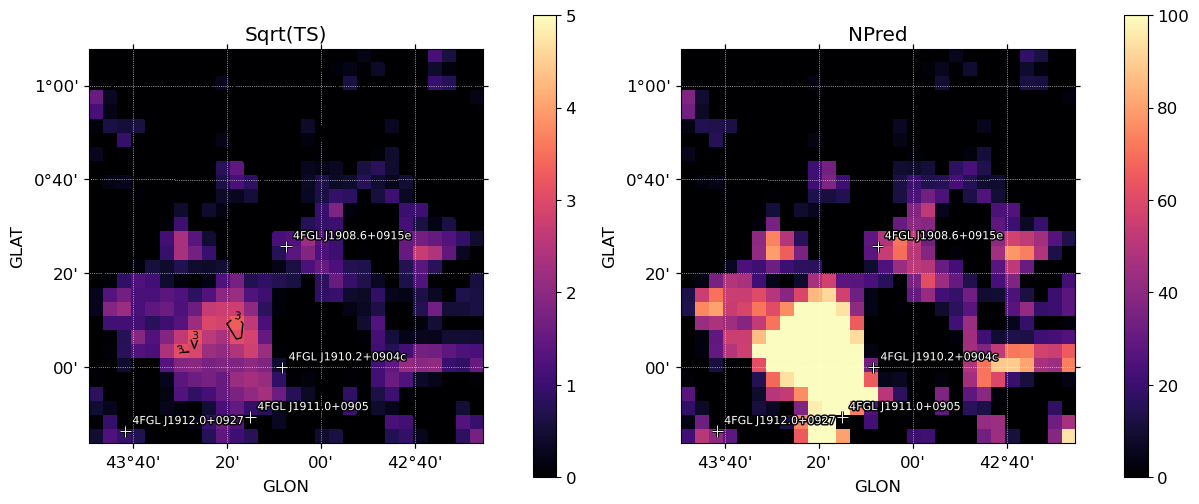

In [25]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_postfit['sqrt_ts'],roi=gta.roi).plot(levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma')
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_postfit['npred'],roi=gta.roi).plot(vmin=0,vmax=100,subplot=122,cmap='magma')
plt.gca().set_title('NPred')
plt.show()

In [ ]:
resid = gta.residmap('SMC_postfit',model={'SpatialModel' : 'PointSource', 'Index' : 2.0},write_fits=True,write_npy=True,make_plots=True)